# EDSL Synthetic Replication -- Pew AI Attitudes Survey (Aug 2023)
**MACS 30755: Digital Experiments**

Replicates Pew Research Center (Aug 2023) AI concern/excitement question using Claude Sonnet 4.5 via EDSL.

**Source:** Pew Research Center, "Growing public concern about the role of artificial intelligence in daily life"
(August 28, 2023, n=11,201 U.S. adults)
**URL:** https://www.pewresearch.org/short-reads/2023/08/28/growing-public-concern-about-the-role-of-artificial-intelligence-in-daily-life/
**Topline PDF:** https://www.pewresearch.org/wp-content/uploads/2023/08/SR_23.08.28_views-of-ai_topline.pdf


In [1]:
# Install EDSL
import subprocess
subprocess.run(["pip", "install", "edsl"], check=True)


CompletedProcess(args=['pip', 'install', 'edsl'], returncode=0)

In [ ]:
import os, json
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Set Expected Parrot API key
os.environ["EXPECTED_PARROT_API_KEY"] = "deleted"


## 1. Human Benchmark Data (Pew Aug 2023, n=11,201)

In [3]:
# Exact Pew question (CNCEXC from Wave 132 topline):
# "Overall, would you say the increased use of artificial intelligence (AI)
#  in daily life makes you feel..."
# Options: More excited than concerned / More concerned than excited /
#          Equally concerned and excited / No answer
#
# Overall results (Jul 31-Aug 6, 2023):
#   More excited than concerned: 10%
#   More concerned than excited: 52%
#   Equally concerned and excited: 36%
#   No answer: 2%
# Source: Pew Wave 132 Science Topline, p.1

OPTIONS = [
    "More excited than concerned",
    "More concerned than excited",
    "Equally concerned and excited",
    "No answer",
]

HUMAN = {
    "overall": {
        "More excited than concerned": 10,
        "More concerned than excited": 52,
        "Equally concerned and excited": 36,
        "No answer": 2,
    },
    "by_age": {
        "18-29": {"More excited than concerned": 17, "More concerned than excited": 42, "Equally concerned and excited": 41, "No answer": 0},
        "30-49": {"More excited than concerned": 11, "More concerned than excited": 50, "Equally concerned and excited": 39, "No answer": 0},
        "50-64": {"More excited than concerned":  8, "More concerned than excited": 57, "Equally concerned and excited": 35, "No answer": 0},
        "65+":   {"More excited than concerned":  4, "More concerned than excited": 61, "Equally concerned and excited": 35, "No answer": 0},
    },
    "by_gender": {
        "Men":   {"More excited than concerned": 14, "More concerned than excited": 48, "Equally concerned and excited": 38, "No answer": 0},
        "Women": {"More excited than concerned":  7, "More concerned than excited": 57, "Equally concerned and excited": 34, "No answer": 0},
    },
    "by_education": {
        "College+":     {"More excited than concerned": 13, "More concerned than excited": 50, "Equally concerned and excited": 37, "No answer": 0},
        "Some college": {"More excited than concerned": 10, "More concerned than excited": 52, "Equally concerned and excited": 36, "No answer": 0},
        "HS or less":   {"More excited than concerned":  8, "More concerned than excited": 55, "Equally concerned and excited": 35, "No answer": 0},
    },
}
print("Human benchmark loaded. Overall:", HUMAN["overall"])


Human benchmark loaded. Overall: {'More excited than concerned': 10, 'More concerned than excited': 52, 'Equally concerned and excited': 36, 'No answer': 2}


## 2. Agent Persona Construction

In [4]:
from edsl import Agent, AgentList, QuestionMultipleChoice, Survey, Model

# Exact question wording from Pew Wave 132 topline (CNCEXC)
# Note: response options 1 and 2 were randomized in the original survey;
# we present them in fixed order here, which is standard for LLM surveys.
# "No answer" is included to allow the model to reflect non-response behavior.
q1 = QuestionMultipleChoice(
    question_name="ai_feeling",
    question_text=(
        "Overall, would you say the increased use of artificial intelligence (AI) "
        "in daily life makes you feel..."
    ),
    question_options=[
        "More excited than concerned",
        "More concerned than excited",
        "Equally concerned and excited",
        "No answer",
    ],
)
survey = Survey(questions=[q1])

# Persona grid -- proportional to Pew 2023 demographic composition
# Age: 18-29 (26%), 30-49 (31%), 50-64 (24%), 65+ (19%)
# Gender: Men (48%), Women (52%)
# Education: College+ (40%), Some college (32%), HS or less (28%)
PERSONAS = [
    # (age_group, gender, education, n_agents)
    ("18-29", "Men",   "College+",     5),
    ("18-29", "Women", "College+",     4),
    ("18-29", "Men",   "Some college", 3),
    ("18-29", "Women", "Some college", 3),
    ("18-29", "Men",   "HS or less",   2),
    ("18-29", "Women", "HS or less",   2),
    ("30-49", "Men",   "College+",     5),
    ("30-49", "Women", "College+",     4),
    ("30-49", "Men",   "Some college", 3),
    ("30-49", "Women", "Some college", 3),
    ("30-49", "Men",   "HS or less",   2),
    ("30-49", "Women", "HS or less",   2),
    ("50-64", "Men",   "College+",     4),
    ("50-64", "Women", "College+",     4),
    ("50-64", "Men",   "Some college", 3),
    ("50-64", "Women", "Some college", 3),
    ("50-64", "Men",   "HS or less",   2),
    ("50-64", "Women", "HS or less",   2),
    ("65+",   "Men",   "College+",     3),
    ("65+",   "Women", "College+",     3),
    ("65+",   "Men",   "Some college", 3),
    ("65+",   "Women", "Some college", 3),
    ("65+",   "Men",   "HS or less",   2),
    ("65+",   "Women", "HS or less",   2),
]

agents = []
for (age, gender, edu, n) in PERSONAS:
    for _ in range(n):
        agents.append(Agent(traits={
            "age_group": age,
            "gender":    gender,
            "education": edu,
            "country":   "United States",
        }))

agent_list = AgentList(agents)
print(f"Created {len(agents)} agents across {len(PERSONAS)} demographic cells")
print("Example agent traits:", agents[0].traits)


Created 72 agents across 24 demographic cells
Example agent traits: {'age_group': '18-29', 'gender': 'Men', 'education': 'College+', 'country': 'United States'}


## 3. Run Survey via EDSL (Expected Parrot + Claude Sonnet 4.5)

In [5]:
# Uses Expected Parrot credits -- no separate Anthropic key needed
# temperature=0 ensures deterministic, fully reproducible results
model = Model("claude-sonnet-4-5-20250929", temperature=0)

results = survey.by(agent_list).by(model).run()

rows = []
for result in results:
    ans = result.answer["ai_feeling"]
    if ans is None:
        ans = "No answer"
    rows.append({**result.agent.traits, "answer": ans})

print(f"Collected {len(rows)} responses")
print("Distribution:", dict(Counter(r["answer"] for r in rows)))

# Save for reproducibility
with open("ai_responses.json", "w") as f:
    json.dump(rows, f, indent=2)
print("Saved to ai_responses.json")


Collected 72 responses
Distribution: {'More excited than concerned': 23, 'More concerned than excited': 49}
Saved to ai_responses.json


## 4. Load Results & Helper Functions

In [6]:
# To skip API call, load saved results instead:
# with open("ai_responses.json") as f:
#     rows = json.load(f)

SHORT = ["More\nexcited", "More\nconcerned", "Equally\nconcerned", "No\nanswer"]
COLORS = ["#2166ac", "#d6604d", "#f4a582", "#cccccc"]

def pct(raw, key, val):
    """Compute % distribution for a demographic subgroup."""
    sub = [r["answer"] for r in raw if r[key] == val]
    n = len(sub)
    if n == 0:
        return {o: 0 for o in OPTIONS}
    c = Counter(sub)
    return {o: round(c.get(o, 0)/n*100, 1) for o in OPTIONS}

def tvd(p, q):
    """Total variation distance (0=identical, higher=more divergent)."""
    return sum(abs(p.get(o,0) - q.get(o,0)) for o in OPTIONS) / 2

ai_overall = {o: round(sum(1 for r in rows if r["answer"]==o)/len(rows)*100, 1)
              for o in OPTIONS}
print("AI overall:", ai_overall)
print("Human overall:", HUMAN["overall"])
print(f"Overall TVD: {tvd(HUMAN['overall'], ai_overall):.1f}")


AI overall: {'More excited than concerned': 31.9, 'More concerned than excited': 68.1, 'Equally concerned and excited': 0.0, 'No answer': 0.0}
Human overall: {'More excited than concerned': 10, 'More concerned than excited': 52, 'Equally concerned and excited': 36, 'No answer': 2}
Overall TVD: 38.0


## 5. Figures

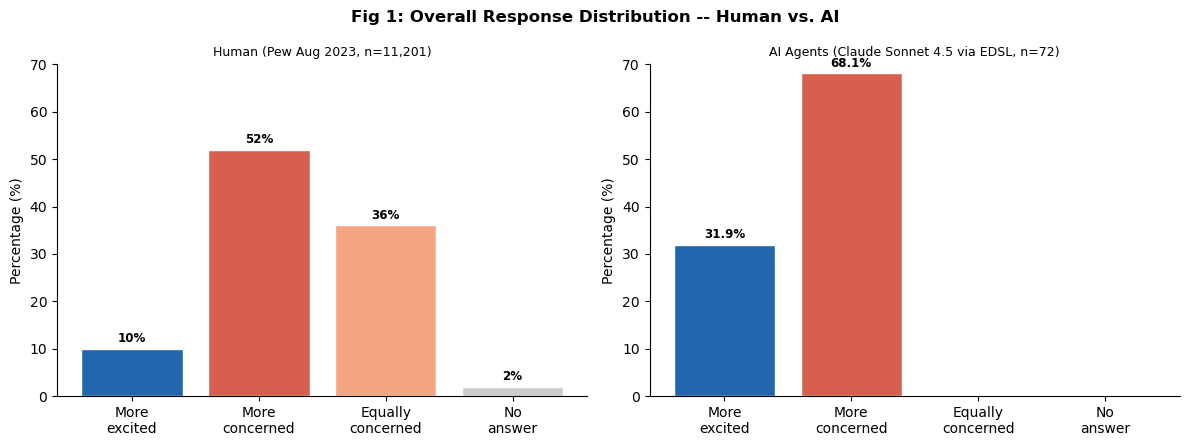

In [7]:
# Fig 1: Overall side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Fig 1: Overall Response Distribution -- Human vs. AI", fontweight="bold")
for ax, (title, data) in zip(axes, [
    (f"Human (Pew Aug 2023, n=11,201)", HUMAN["overall"]),
    (f"AI Agents (Claude Sonnet 4.5 via EDSL, n={len(rows)})", ai_overall)
]):
    vals = [data[o] for o in OPTIONS]
    bars = ax.bar(SHORT, vals, color=COLORS, edgecolor="white")
    ax.set_title(title, fontsize=9); ax.set_ylim(0, 70)
    ax.set_ylabel("Percentage (%)")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.8, f"{v}%",
                    ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig1_overall.png", bbox_inches="tight", dpi=150)
plt.show()


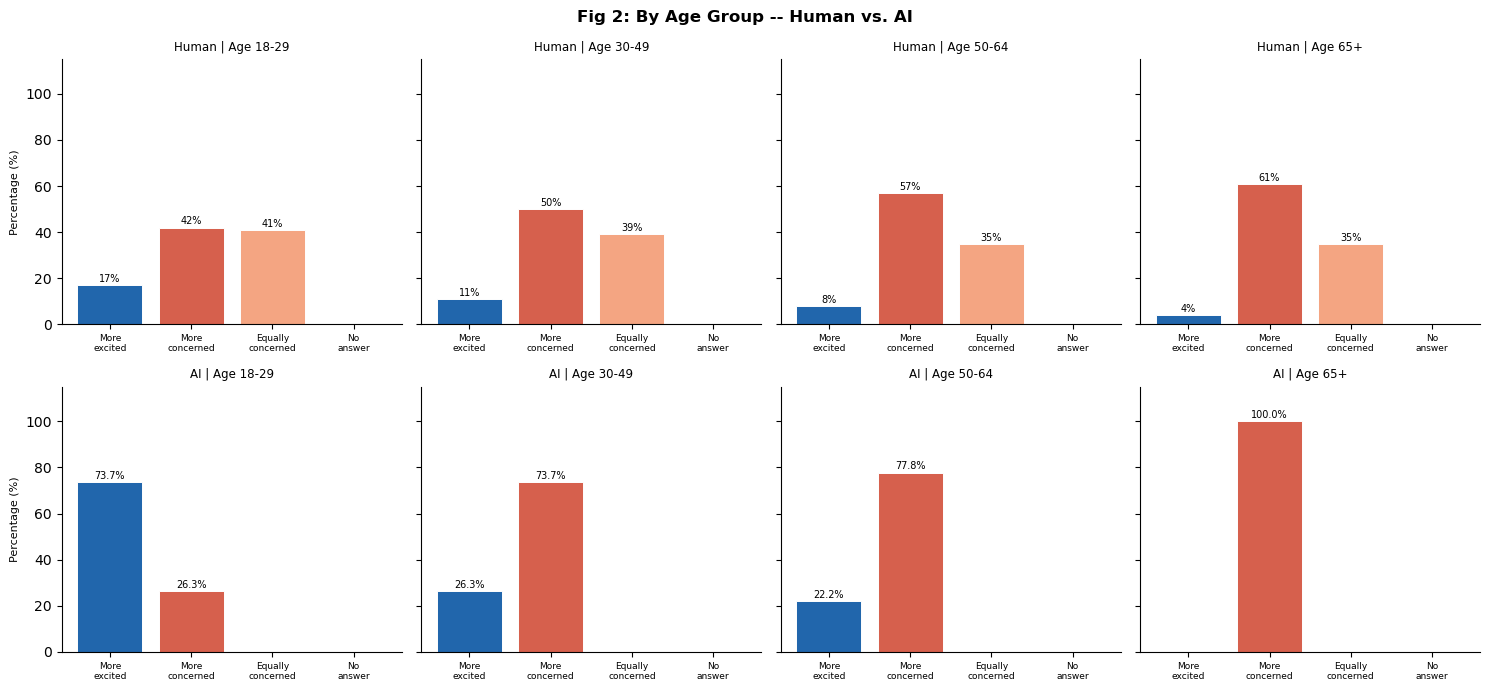

Age 18-29 TVD: 56.7
Age 30-49 TVD: 39.0
Age 50-64 TVD: 35.0
Age 65+ TVD: 39.0


In [8]:
# Fig 2: By age group
ages = ["18-29", "30-49", "50-64", "65+"]
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=True)
fig.suptitle("Fig 2: By Age Group -- Human vs. AI", fontweight="bold")
for col, age in enumerate(ages):
    for row, (lbl, data) in enumerate([
        ("Human", HUMAN["by_age"][age]),
        ("AI",    pct(rows, "age_group", age))
    ]):
        ax = axes[row][col]
        vals = [data[o] for o in OPTIONS]
        bars = ax.bar(SHORT, vals, color=COLORS, edgecolor="white", linewidth=0.7)
        ax.set_title(f"{'Human' if row==0 else 'AI'} | Age {age}", fontsize=8.5)
        ax.set_ylim(0, 115); ax.tick_params(axis="x", labelsize=6.5)
        if col == 0: ax.set_ylabel("Percentage (%)", fontsize=8)
        for bar, v in zip(bars, vals):
            if v > 2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.5,
                              f"{v}%", ha="center", va="bottom", fontsize=7)
        ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig2_by_age.png", bbox_inches="tight", dpi=150)
plt.show()
for age in ages:
    print(f"Age {age} TVD: {tvd(HUMAN['by_age'][age], pct(rows,'age_group',age)):.1f}")


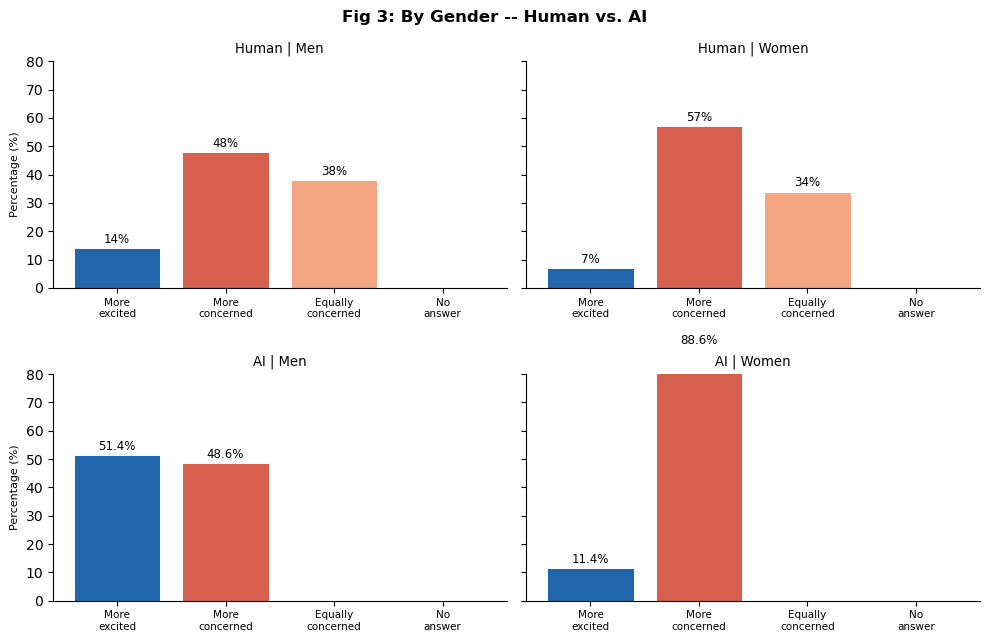

Men TVD: 38.0
Women TVD: 35.0


In [9]:
# Fig 3: By gender
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharey=True)
fig.suptitle("Fig 3: By Gender -- Human vs. AI", fontweight="bold")
for col, g in enumerate(["Men", "Women"]):
    for row, (lbl, data) in enumerate([
        ("Human", HUMAN["by_gender"][g]),
        ("AI",    pct(rows, "gender", g))
    ]):
        ax = axes[row][col]
        vals = [data[o] for o in OPTIONS]
        bars = ax.bar(SHORT, vals, color=COLORS, edgecolor="white", linewidth=0.7)
        ax.set_title(f"{'Human' if row==0 else 'AI'} | {g}", fontsize=9.5)
        ax.set_ylim(0, 80); ax.tick_params(axis="x", labelsize=7.5)
        if col == 0: ax.set_ylabel("Percentage (%)", fontsize=8)
        for bar, v in zip(bars, vals):
            if v > 2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.8,
                              f"{v}%", ha="center", va="bottom", fontsize=8.5)
        ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig3_by_gender.png", bbox_inches="tight", dpi=150)
plt.show()
for g in ["Men", "Women"]:
    print(f"{g} TVD: {tvd(HUMAN['by_gender'][g], pct(rows,'gender',g)):.1f}")


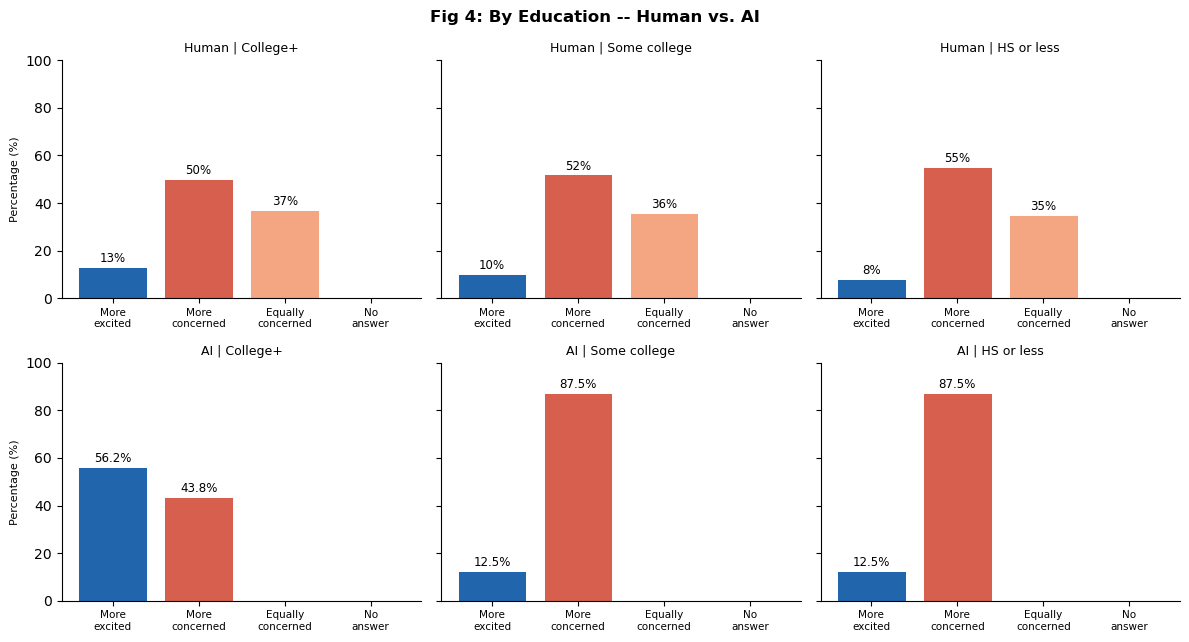

College+ TVD: 43.2
Some college TVD: 37.0
HS or less TVD: 36.0


In [10]:
# Fig 4: By education
edu_groups = ["College+", "Some college", "HS or less"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), sharey=True)
fig.suptitle("Fig 4: By Education -- Human vs. AI", fontweight="bold")
for col, edu in enumerate(edu_groups):
    for row, (lbl, data) in enumerate([
        ("Human", HUMAN["by_education"][edu]),
        ("AI",    pct(rows, "education", edu))
    ]):
        ax = axes[row][col]
        vals = [data[o] for o in OPTIONS]
        bars = ax.bar(SHORT, vals, color=COLORS, edgecolor="white", linewidth=0.7)
        ax.set_title(f"{'Human' if row==0 else 'AI'} | {edu}", fontsize=9)
        ax.set_ylim(0, 100); ax.tick_params(axis="x", labelsize=7.5)
        if col == 0: ax.set_ylabel("Percentage (%)", fontsize=8)
        for bar, v in zip(bars, vals):
            if v > 2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.8,
                              f"{v}%", ha="center", va="bottom", fontsize=8.5)
        ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig4_by_edu.png", bbox_inches="tight", dpi=150)
plt.show()
for edu in edu_groups:
    print(f"{edu} TVD: {tvd(HUMAN['by_education'][edu], pct(rows,'education',edu)):.1f}")


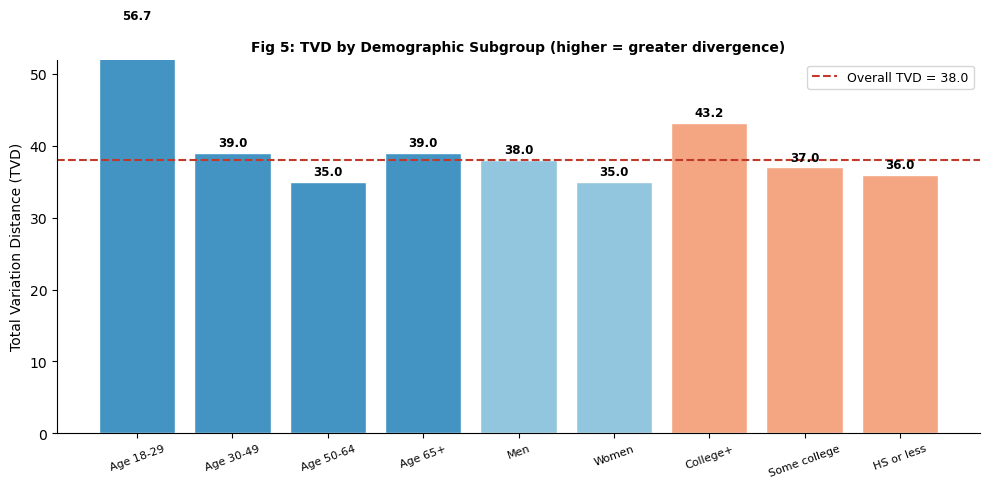

In [14]:
# Fig 5: TVD summary
subgroups = ["Age 18-29","Age 30-49","Age 50-64","Age 65+",
             "Men","Women","College+","Some college","HS or less"]
tvds = [
    tvd(HUMAN["by_age"]["18-29"],    pct(rows,"age_group","18-29")),
    tvd(HUMAN["by_age"]["30-49"],    pct(rows,"age_group","30-49")),
    tvd(HUMAN["by_age"]["50-64"],    pct(rows,"age_group","50-64")),
    tvd(HUMAN["by_age"]["65+"],      pct(rows,"age_group","65+")),
    tvd(HUMAN["by_gender"]["Men"],   pct(rows,"gender","Men")),
    tvd(HUMAN["by_gender"]["Women"], pct(rows,"gender","Women")),
    tvd(HUMAN["by_education"]["College+"],     pct(rows,"education","College+")),
    tvd(HUMAN["by_education"]["Some college"], pct(rows,"education","Some college")),
    tvd(HUMAN["by_education"]["HS or less"],   pct(rows,"education","HS or less")),
]
bar_colors = ["#4393c3"]*4 + ["#92c5de"]*2 + ["#f4a582"]*3
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(subgroups, tvds, color=bar_colors, edgecolor="white")
overall_tvd = tvd(HUMAN["overall"], ai_overall)
ax.axhline(y=overall_tvd, color="#c0392b", linestyle="--", linewidth=1.5,
           label=f"Overall TVD = {overall_tvd:.1f}")
for bar, v in zip(bars, tvds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.5, f"{v:.1f}",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax.set_ylabel("Total Variation Distance (TVD)")
ax.set_ylim(0, 52)
ax.tick_params(axis="x", labelsize=8, rotation=20)
ax.set_title("Fig 5: TVD by Demographic Subgroup (higher = greater divergence)",
             fontweight="bold", fontsize=10)
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_tvd.png", bbox_inches="tight", dpi=150)
plt.show()


## 6. Summary Statistics

In [15]:
edu_groups = ["College+", "Some college", "HS or less"]
print(f"{'Subgroup':<22} {'H Excited%':>10} {'AI Excited%':>12} {'H Concern%':>11} {'AI Concern%':>12} {'H NoAns%':>9} {'AI NoAns%':>10} {'TVD':>6}")
print("-"*95)
for age in ages:
    hd = HUMAN["by_age"][age]
    ad = pct(rows, "age_group", age)
    print(f"  Age {age:<18} "
          f"{hd['More excited than concerned']:>10} {ad['More excited than concerned']:>12} "
          f"{hd['More concerned than excited']:>11} {ad['More concerned than excited']:>12} "
          f"{hd['No answer']:>9} {ad['No answer']:>10} "
          f"{tvd(hd,ad):>6.1f}")
for edu in edu_groups:
    hd = HUMAN["by_education"][edu]
    ad = pct(rows, "education", edu)
    print(f"  {edu:<22} "
          f"{hd['More excited than concerned']:>10} {ad['More excited than concerned']:>12} "
          f"{hd['More concerned than excited']:>11} {ad['More concerned than excited']:>12} "
          f"{hd['No answer']:>9} {ad['No answer']:>10} "
          f"{tvd(hd,ad):>6.1f}")
print()
print(f"  Overall TVD: {tvd(HUMAN['overall'], ai_overall):.1f}")
print()
# Report No answer rate for AI
na_rate = round(sum(1 for r in rows if r["answer"]=="No answer")/len(rows)*100, 1)
print(f"  AI 'No answer' rate: {na_rate}% (Human: 2%)")
print("Note: TVD = Total Variation Distance (0=identical, higher=more divergent)")


Subgroup               H Excited%  AI Excited%  H Concern%  AI Concern%  H NoAns%  AI NoAns%    TVD
-----------------------------------------------------------------------------------------------
  Age 18-29                      17         73.7          42         26.3         0        0.0   56.7
  Age 30-49                      11         26.3          50         73.7         0        0.0   39.0
  Age 50-64                       8         22.2          57         77.8         0        0.0   35.0
  Age 65+                         4          0.0          61        100.0         0        0.0   39.0
  College+                       13         56.2          50         43.8         0        0.0   43.2
  Some college                   10         12.5          52         87.5         0        0.0   37.0
  HS or less                      8         12.5          55         87.5         0        0.0   36.0

  Overall TVD: 38.0

  AI 'No answer' rate: 0.0% (Human: 2%)
Note: TVD = Total Variation 